# 244. Shortest Word Distance II
https://leetcode.com/problems/shortest-word-distance-ii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Brute Force per query | O(n) per query | O(1) | Scan entire array each time |
| **Precompute + Two Pointers** | **O(m+k) per query** | **O(n)** | **Store index lists, merge-scan** |

## Methodology

We **precompute** a hash map from each word to its sorted list of indices. For each `shortest()` query, we retrieve the two index lists and use a **two-pointer merge** to find the minimum absolute difference. Since the lists are sorted, we advance the pointer with the smaller index, achieving O(m+k) per query where m and k are the list lengths.

## Solutions

### C#

In [ ]:
// 244. Shortest Word Distance II
// Constructor: O(n) | shortest(): O(m+k) | Space: O(n)
public class WordDistance {
    private Dictionary<string, List<int>> indices;
    
    public WordDistance(string[] wordsDict) {
        indices = new Dictionary<string, List<int>>();
        for (int i = 0; i < wordsDict.Length; i++) {
            if (!indices.ContainsKey(wordsDict[i]))
                indices[wordsDict[i]] = new List<int>();
            indices[wordsDict[i]].Add(i);
        }
    }
    
    public int Shortest(string word1, string word2) {
        var list1 = indices[word1];
        var list2 = indices[word2];
        int i = 0, j = 0, minDist = int.MaxValue;
        
        while (i < list1.Count && j < list2.Count) {
            minDist = Math.Min(minDist, Math.Abs(list1[i] - list2[j]));
            if (list1[i] < list2[j]) i++;
            else j++;
        }
        return minDist;
    }
}

### Python

In [ ]:
# 244. Shortest Word Distance II
# Constructor: O(n) | shortest(): O(m+k) | Space: O(n)
from collections import defaultdict

class WordDistance:
    def __init__(self, wordsDict: list[str]):
        self.indices = defaultdict(list)
        for i, word in enumerate(wordsDict):
            self.indices[word].append(i)
    
    def shortest(self, word1: str, word2: str) -> int:
        list1, list2 = self.indices[word1], self.indices[word2]
        i = j = 0
        min_dist = float('inf')
        
        while i < len(list1) and j < len(list2):
            min_dist = min(min_dist, abs(list1[i] - list2[j]))
            if list1[i] < list2[j]:
                i += 1
            else:
                j += 1
        return min_dist

### Go

In [ ]:
// 244. Shortest Word Distance II
// Constructor: O(n) | Shortest(): O(m+k) | Space: O(n)
type WordDistance struct {
    indices map[string][]int
}

func Constructor(wordsDict []string) WordDistance {
    wd := WordDistance{indices: make(map[string][]int)}
    for i, word := range wordsDict {
        wd.indices[word] = append(wd.indices[word], i)
    }
    return wd
}

func (wd *WordDistance) Shortest(word1 string, word2 string) int {
    list1, list2 := wd.indices[word1], wd.indices[word2]
    i, j, minDist := 0, 0, 1<<31-1
    
    for i < len(list1) && j < len(list2) {
        d := list1[i] - list2[j]
        if d < 0 {
            d = -d
        }
        if d < minDist {
            minDist = d
        }
        if list1[i] < list2[j] {
            i++
        } else {
            j++
        }
    }
    return minDist
}

### Rust

In [ ]:
// 244. Shortest Word Distance II
// Constructor: O(n) | shortest(): O(m+k) | Space: O(n)
use std::collections::HashMap;

struct WordDistance {
    indices: HashMap<String, Vec<usize>>,
}

impl WordDistance {
    fn new(words_dict: Vec<String>) -> Self {
        let mut indices = HashMap::new();
        for (i, word) in words_dict.iter().enumerate() {
            indices.entry(word.clone()).or_insert_with(Vec::new).push(i);
        }
        WordDistance { indices }
    }
    
    fn shortest(&self, word1: String, word2: String) -> i32 {
        let list1 = &self.indices[&word1];
        let list2 = &self.indices[&word2];
        let (mut i, mut j) = (0, 0);
        let mut min_dist = i32::MAX;
        
        while i < list1.len() && j < list2.len() {
            let dist = (list1[i] as i32 - list2[j] as i32).abs();
            min_dist = min_dist.min(dist);
            if list1[i] < list2[j] {
                i += 1;
            } else {
                j += 1;
            }
        }
        min_dist
    }
}

## Example Scenarios

### 1. Common Case — Adjacent Words
**Input:** `words = ["practice","makes","perfect","coding","makes"]`, `shortest("makes","coding")`

Indices of `"makes"`: `[1, 4]`. Indices of `"coding"`: `[3]`. Two-pointer comparison: $|1-3| = 2$, $|4-3| = 1$. Minimum distance is `1`.

### 2. Slightly Complex — Multiple Occurrences
**Input:** `words = ["a","b","a","c","b","a"]`, `shortest("a","b")`

Indices of `"a"`: `[0, 2, 5]`. Indices of `"b"`: `[1, 4]`. The two-pointer merge finds minimum $|0-1| = 1$ immediately. Even with many occurrences, the merge runs in $O(m + k)$ where $m$ and $k$ are the list lengths.

### 3. Edge Case: Time Factor — Frequent Queries
**Input:** $n = 5 \times 10^4$ words, $10^4$ calls to `shortest()`

The constructor builds the index map in $O(n)$. Each query runs the two-pointer merge in $O(m + k)$. Without pre-indexing, each query would scan all $n$ words — the hashmap trades $O(n)$ constructor time for fast repeated lookups.

### 4. Edge Case: Space Factor — All Unique Words
**Input:** `words = ["w1","w2","w3",...,"w50000"]` (all unique)

The hashmap stores $n = 5 \times 10^4$ entries, each with a single-element index list. Total space: $O(n)$ for the map plus $O(n)$ for all index lists combined. Each `shortest()` call compares exactly two singleton lists in $O(1)$.

### 5. Almost-Impossible but Plausible — Same Word Everywhere
**Input:** `words = ["x","y","x","y",...,"x","y"]` ($25{,}000$ `"x"`s and $25{,}000$ `"y"`s alternating), `shortest("x","y")`

Both index lists have $25{,}000$ entries. The two-pointer merge walks both lists simultaneously — $O(m + k) = O(50{,}000)$ per query. The answer is always `1` since `"x"` and `"y"` alternate. This tests the worst case for query time within the constraint limits.

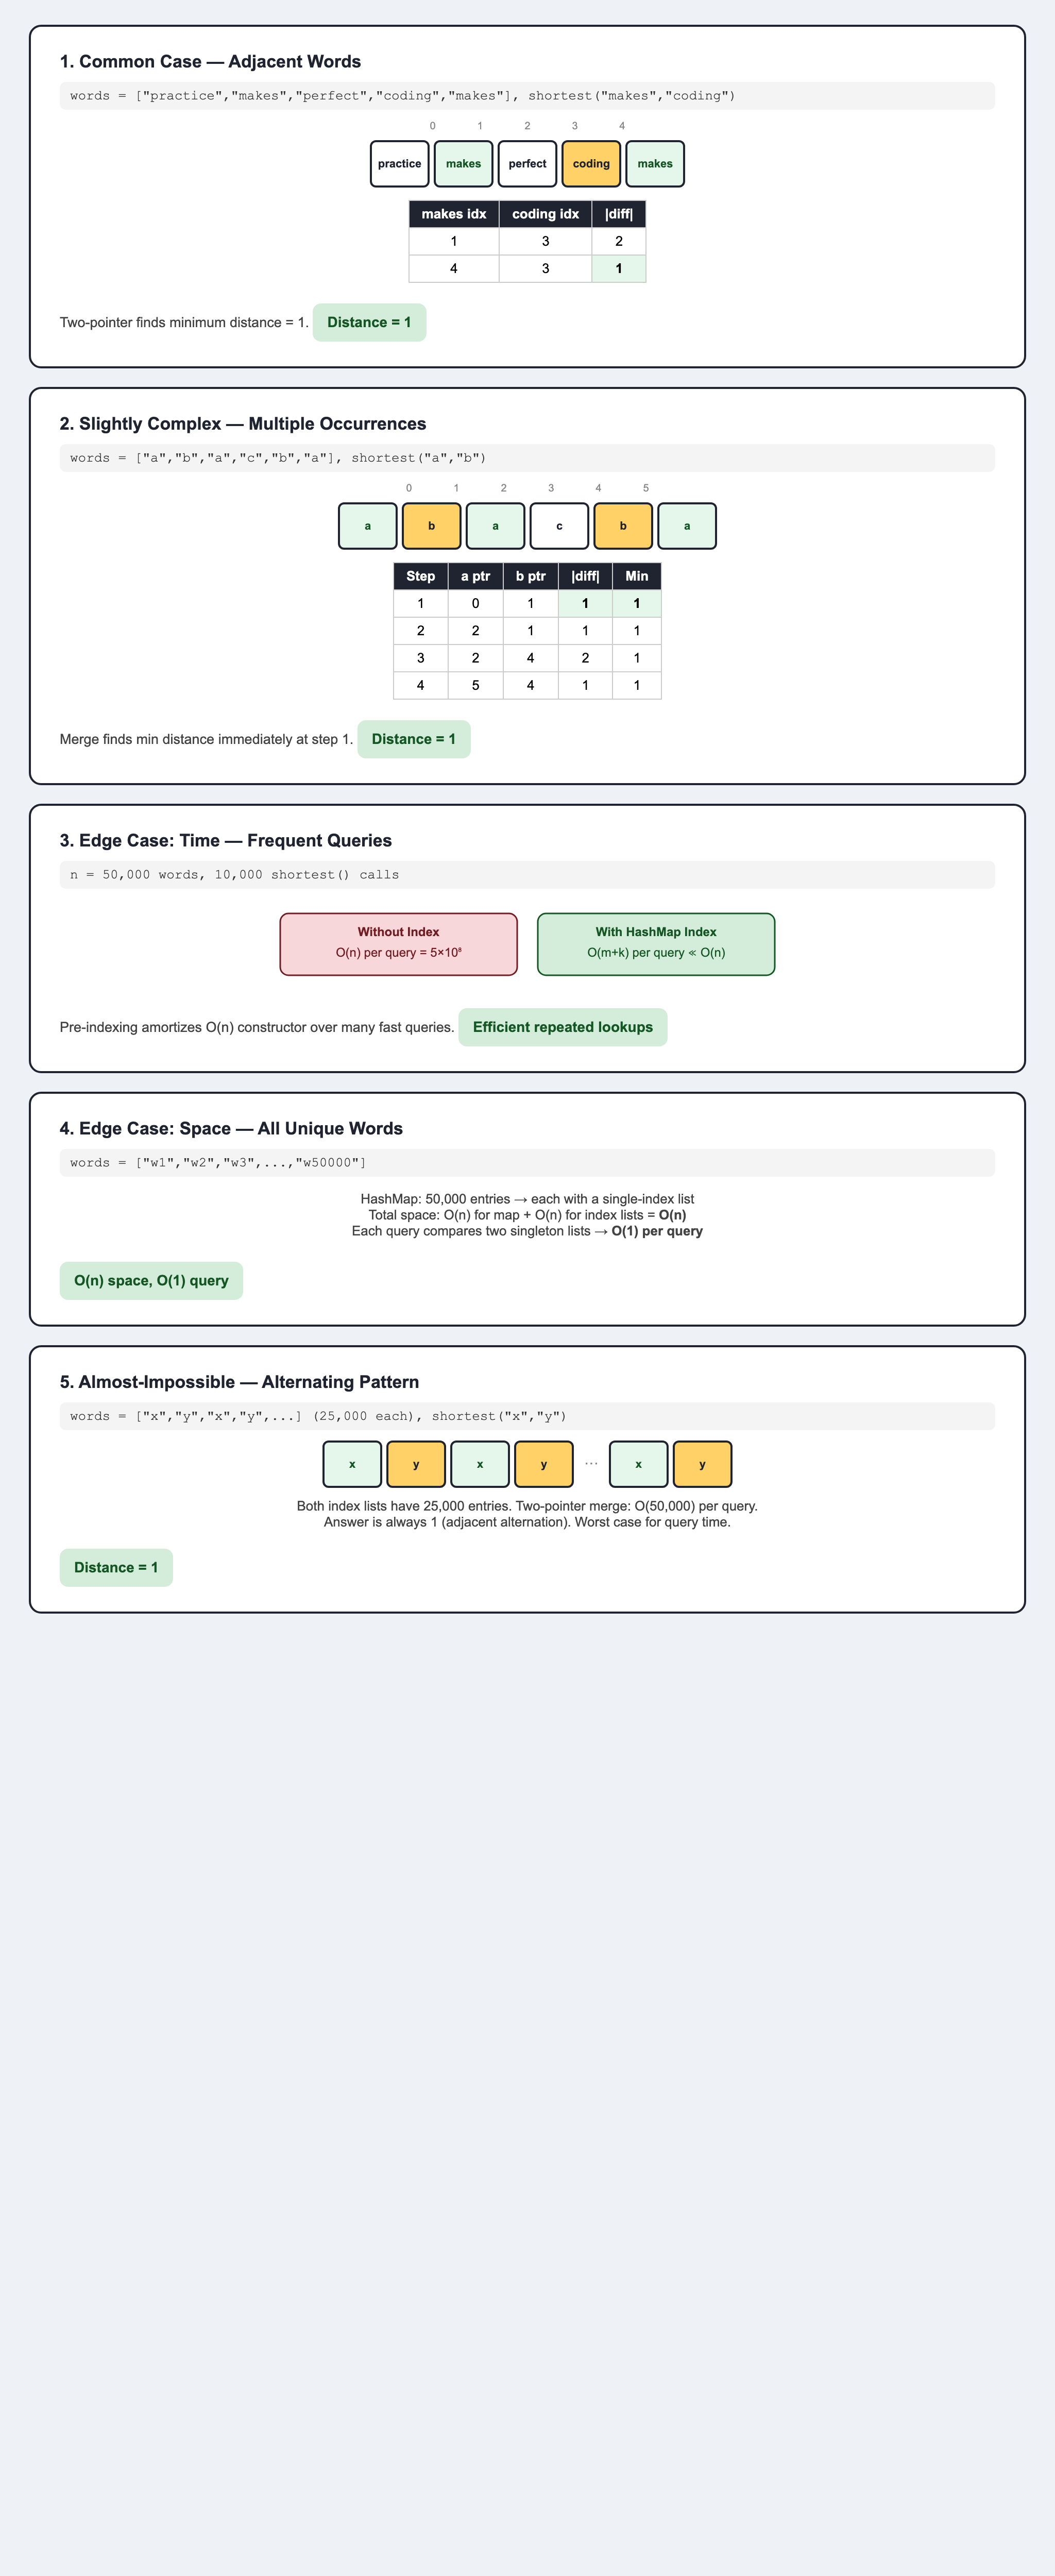